# JS04 Regression - Lab 2
## Support Vector Regression (SVR)

This lab trains an RBF-kernel SVR model to estimate salary from position level.

## Step 1: Import Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR

## Step 2: Load Dataset

In [2]:
dataset = pd.read_csv('Posisi_gaji.csv')
display(dataset)
print(f'Dataset shape: {dataset.shape}')

required_columns = ['Posisi', 'Level', 'Gaji']
assert list(dataset.columns) == required_columns
assert dataset['Level'].isna().sum() == 0
assert dataset['Gaji'].isna().sum() == 0

X_original = dataset.iloc[:, 1:2].to_numpy()
y_original = dataset.iloc[:, 2].to_numpy().reshape(-1, 1)
print(f'Position levels: {X_original.ravel()}')
print(f'Salary range: {y_original.min():,.0f} - {y_original.max():,.0f}')

,Posisi,Level,Gaji
0,Business Analyst,1,45000
1,Junior Consultant,2,50000
2,Senior Consultant,3,60000
3,Manager,4,80000
4,Country Manager,5,110000
5,Region Manager,6,150000
6,Partner,7,200000
7,Senior Partner,8,300000
8,C-level,9,500000
9,CEO,10,1000000


Dataset shape: (10, 3)
Position levels: [ 1  2  3  4  5  6  7  8  9 10]
Salary range: 45,000 - 1,000,000


## Step 3: Feature Scaling

SVR is sensitive to feature scale, so both the position level and salary are standardized before training.

In [3]:
sc_X = StandardScaler()
sc_y = StandardScaler()
X = sc_X.fit_transform(X_original)
y = sc_y.fit_transform(y_original).ravel()

print(f'Scaled feature mean: {X.mean():.6f}')
print(f'Scaled target mean: {y.mean():.6f}')
assert X.shape == (len(dataset), 1)
assert y.shape == (len(dataset),)

Scaled feature mean: -0.000000
Scaled target mean: -0.000000


## Step 4: Fit the SVR Model

In [4]:
regressor = SVR(kernel='rbf')
regressor.fit(X, y)
print(regressor)

SVR()


## Step 5: Visualize SVR Results

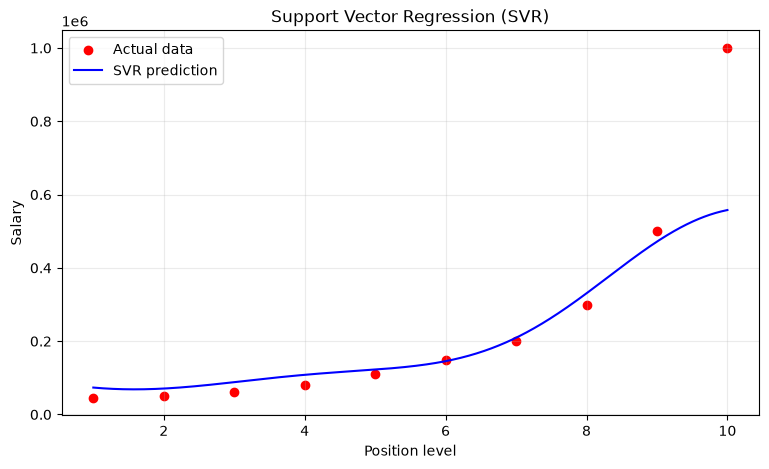

In [5]:
X_grid_original = np.arange(X_original.min(), X_original.max() + 0.01, 0.01).reshape(-1, 1)
X_grid = sc_X.transform(X_grid_original)
y_grid_scaled = regressor.predict(X_grid)
y_grid_original = sc_y.inverse_transform(y_grid_scaled.reshape(-1, 1)).ravel()

plt.figure(figsize=(9, 5))
plt.scatter(X_original.ravel(), y_original.ravel(), color='red', label='Actual data')
plt.plot(X_grid_original.ravel(), y_grid_original, color='blue', label='SVR prediction')
plt.title('Support Vector Regression (SVR)')
plt.xlabel('Position level')
plt.ylabel('Salary')
plt.legend()
plt.grid(alpha=0.25)
plt.show()

## Step 6-7: Predict and Display a Result

In [6]:
position_level_pred = np.array([[6.5]])
position_level_pred_scaled = sc_X.transform(position_level_pred)
salary_pred_scaled = regressor.predict(position_level_pred_scaled)
salary_pred = sc_y.inverse_transform(salary_pred_scaled.reshape(-1, 1)).ravel()

print(f'Predicted Salary for Position Level 6.5: {salary_pred[0]:,.2f}')
assert salary_pred.shape == (1,)
assert np.isfinite(salary_pred[0])

Predicted Salary for Position Level 6.5: 170,370.02


## Step 8: Evaluate the SVR Model

The first metrics reproduce the module's evaluation on standardized values. The second set is easier to interpret because it is expressed in salary units.

In [7]:
y_actual_scaled = y
y_pred_scaled = regressor.predict(X)

mae_scaled = mean_absolute_error(y_actual_scaled, y_pred_scaled)
mse_scaled = mean_squared_error(y_actual_scaled, y_pred_scaled)
rmse_scaled = np.sqrt(mse_scaled)
r2_scaled = r2_score(y_actual_scaled, y_pred_scaled)

y_pred_original = sc_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()
mae_original = mean_absolute_error(y_original.ravel(), y_pred_original)
mse_original = mean_squared_error(y_original.ravel(), y_pred_original)
rmse_original = np.sqrt(mse_original)
r2_original = r2_score(y_original.ravel(), y_pred_original)

print('Metrics on standardized salary values:')
print(f'MAE: {mae_scaled:.6f}')
print(f'MSE: {mse_scaled:.6f}')
print(f'RMSE: {rmse_scaled:.6f}')
print(f'R-squared: {r2_scaled:.6f}')
print('\nMetrics on original salary values:')
print(f'MAE: {mae_original:,.2f}')
print(f'MSE: {mse_original:,.2f}')
print(f'RMSE: {rmse_original:,.2f}')
print(f'R-squared: {r2_original:.6f}')

assert np.isfinite([mae_scaled, mse_scaled, rmse_scaled, r2_scaled]).all()
assert np.isfinite([mae_original, mse_original, rmse_original, r2_original]).all()

Metrics on standardized salary values:
MAE: 0.222993
MSE: 0.248400
RMSE: 0.498397
R-squared: 0.751600

Metrics on original salary values:
MAE: 63,332.39
MSE: 20,036,494,264.13
RMSE: 141,550.32
R-squared: 0.751600


## Conclusion

The RBF SVR model captures the non-linear relationship between position level and salary. Scaling is reversed after prediction so the estimate can be read in the original salary units.